In [1]:
import os

os.chdir('MultiBench')

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from datasets.affect.get_data import get_dataloader

traindata, validdata, testdata = get_dataloader(
    'data/mosi_raw.pkl', robust_test=False, max_pad=True, data_type='mosi', max_seq_len=50, num_workers=0)

Training data shape: (1283, 50, 300)
Validation data shape: (214, 50, 300)
Test data shape: (686, 50, 300)
Label range: -3.0 to 3.0
Class distribution: Counter({4: 1010, 0: 120, 1: 62, 2: 53, 3: 38})


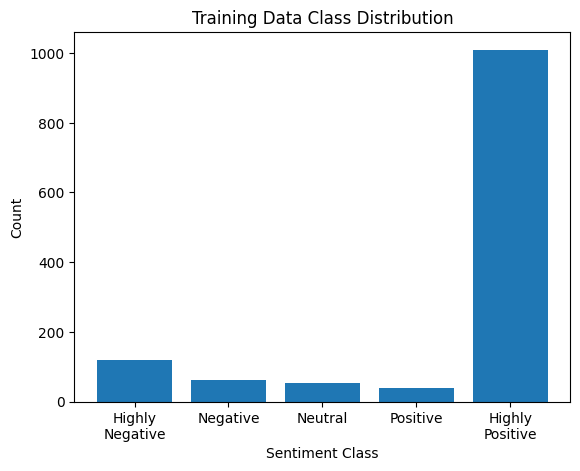

In [4]:
# Check data dimensions and label distribution
print("Training data shape:", traindata.dataset.dataset['text'].shape)
print("Validation data shape:", validdata.dataset.dataset['text'].shape)
print("Test data shape:", testdata.dataset.dataset['text'].shape)

# Analyze label distribution
train_labels = traindata.dataset.dataset['labels']
print("Label range:", np.min(train_labels), "to", np.max(train_labels))

# Convert continuous labels to 5 classes as mentioned in the paper
def convert_to_5class(labels):
    """Convert 7-point scale to 5-point scale as mentioned in the paper"""
    # Mapping: [-3,-2,-1,0,1,2,3] to [0,1,2,3,4]
    # Highly negative: -3,-2 -> 0
    # Negative: -1 -> 1
    # Neutral: 0 -> 2
    # Positive: 1 -> 3
    # Highly positive: 2,3 -> 4
    converted = []
    for label in labels:
        if label <= -2:
            converted.append(0)  # Highly negative
        elif label == -1:
            converted.append(1)  # Negative
        elif label == 0:
            converted.append(2)  # Neutral
        elif label == 1:
            converted.append(3)  # Positive
        else:  # label >= 2
            converted.append(4)  # Highly positive
    return np.array(converted)

train_5class = convert_to_5class(train_labels)
class_counts = Counter(train_5class)
print("Class distribution:", class_counts)

# Plot class distribution
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
plt.title('Training Data Class Distribution')
plt.xticks([0,1,2,3,4], ['Highly\nNegative', 'Negative', 'Neutral', 'Positive', 'Highly\nPositive'])
plt.show()


In [ ]:
class TextUnimodalModel(nn.Module):
    def __init__(self, input_dim=300, hidden_dim=128, output_dim=5):
        super(TextUnimodalModel, self).__init__()
        
        # LSTM layer as described in the paper
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        
        # Fully connected layers with ReLU activation
        self.fc1 = nn.Linear(hidden_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.relu = nn.ReLU()
        
        # Output layer for 5-class classification
        self.output = nn.Linear(128, output_dim)
        
    def forward(self, x, lengths=None):
        # LSTM forward pass
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        # Use the last hidden state
        if lengths is not None:
            # Get the last valid hidden state for each sequence
            batch_size = x.size(0)
            last_hidden_states = torch.zeros(batch_size, lstm_out.size(2)).to(x.device)
            for i, length in enumerate(lengths):
                last_hidden_states[i] = lstm_out[i, length-1]
        else:
            # If lengths not provided, use the final hidden state
            last_hidden_states = h_n.squeeze(0)
        
        # Pass through fully connected layers
        x = self.relu(self.fc1(last_hidden_states))
        x = self.relu(self.fc2(x))
        
        # Output layer
        output = self.output(x)
        return output

In [7]:
def train_model(model, train_loader, val_loader, num_epochs=50, learning_rate=5e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch in train_loader:
            # Extract text data and labels
            text = batch[2]  # Text is the third element
            labels = batch[3].squeeze()  # Labels are the fourth element
            
            # Convert to 5-class labels
            labels_5class = convert_to_5class(labels.numpy())
            labels_5class = torch.tensor(labels_5class, dtype=torch.long)
            
            optimizer.zero_grad()
            outputs = model(text)
            loss = criterion(outputs, labels_5class)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels_5class.size(0)
            train_correct += (predicted == labels_5class).sum().item()
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for batch in val_loader:
                text = batch[2]
                labels = batch[3].squeeze()
                
                labels_5class = convert_to_5class(labels.numpy())
                labels_5class = torch.tensor(labels_5class, dtype=torch.long)
                
                outputs = model(text)
                loss = criterion(outputs, labels_5class)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels_5class.size(0)
                val_correct += (predicted == labels_5class).sum().item()
        
        # Calculate metrics
        train_loss_avg = train_loss / len(train_loader)
        val_loss_avg = val_loss / len(val_loader)
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total
        
        train_losses.append(train_loss_avg)
        val_losses.append(val_loss_avg)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Train Loss: {train_loss_avg:.4f}, Val Loss: {val_loss_avg:.4f}, '
              f'Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')
    
    return model, train_losses, val_losses, train_accuracies, val_accuracies

def evaluate_model(model, test_loader):
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            text = batch[2]
            labels = batch[3].squeeze()
            
            labels_5class = convert_to_5class(labels.numpy())
            
            outputs = model(text)
            _, predicted = torch.max(outputs.data, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels_5class)
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average='weighted')
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)
    
    return accuracy, precision, recall, f1, cm

def plot_results(train_losses, val_losses, train_accuracies, val_accuracies, cm):
    # Plot loss curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    # Plot accuracy curves
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.show()
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Highly\nNegative', 'Negative', 'Neutral', 'Positive', 'Highly\nPositive'],
                yticklabels=['Highly\nNegative', 'Negative', 'Neutral', 'Positive', 'Highly\nPositive'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


In [8]:
def handle_class_imbalance(train_loader, class_counts):
    # Calculate class weights
    total_samples = sum(class_counts.values())
    class_weights = {i: total_samples / (len(class_counts) * count) 
                    for i, count in class_counts.items()}
    
    # Convert to tensor for PyTorch
    weights = torch.tensor([class_weights[i] for i in range(5)], dtype=torch.float)
    
    # Use weighted loss function
    criterion = nn.CrossEntropyLoss(weight=weights)
    
    return criterion


Epoch 1/50, Train Loss: 1.2668, Val Loss: 0.8712, Train Acc: 62.35%, Val Acc: 76.17%
Epoch 2/50, Train Loss: 0.7882, Val Loss: 0.8636, Train Acc: 78.72%, Val Acc: 76.17%
Epoch 3/50, Train Loss: 0.8084, Val Loss: 0.8633, Train Acc: 78.72%, Val Acc: 76.17%
Epoch 4/50, Train Loss: 0.7842, Val Loss: 0.8811, Train Acc: 78.72%, Val Acc: 76.17%
Epoch 5/50, Train Loss: 0.8004, Val Loss: 0.8643, Train Acc: 78.72%, Val Acc: 76.17%
Epoch 6/50, Train Loss: 0.7889, Val Loss: 0.8836, Train Acc: 78.72%, Val Acc: 76.17%
Epoch 7/50, Train Loss: 0.7872, Val Loss: 0.8674, Train Acc: 78.72%, Val Acc: 76.17%
Epoch 8/50, Train Loss: 0.7817, Val Loss: 0.8637, Train Acc: 78.72%, Val Acc: 76.17%
Epoch 9/50, Train Loss: 0.7827, Val Loss: 0.8748, Train Acc: 78.72%, Val Acc: 76.17%
Epoch 10/50, Train Loss: 0.8027, Val Loss: 0.8677, Train Acc: 78.72%, Val Acc: 76.17%
Epoch 11/50, Train Loss: 0.7879, Val Loss: 0.8637, Train Acc: 78.72%, Val Acc: 76.17%
Epoch 12/50, Train Loss: 0.7843, Val Loss: 0.8645, Train Acc: 7

h:\Programs\Anaconda\envs\multimodal\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Test Accuracy: 0.6706
Test Precision: 0.5506
Test Recall: 0.6706
Test F1 Score: 0.5410


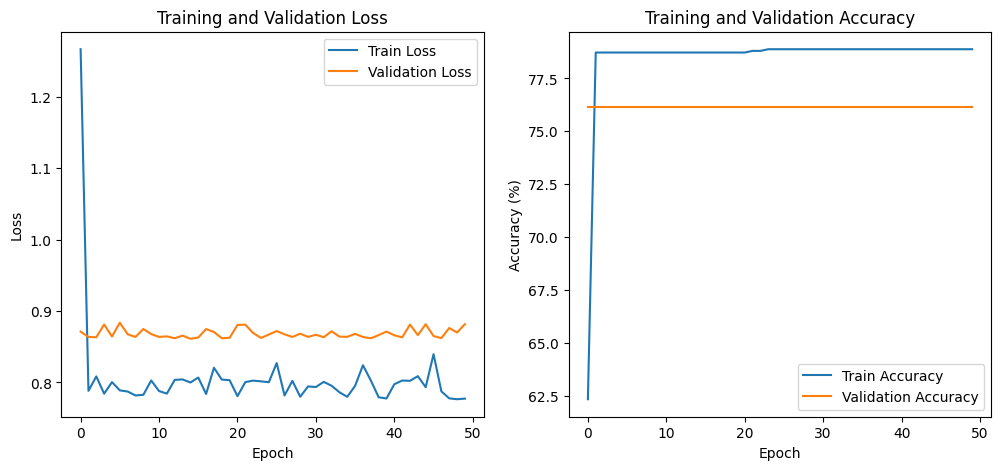

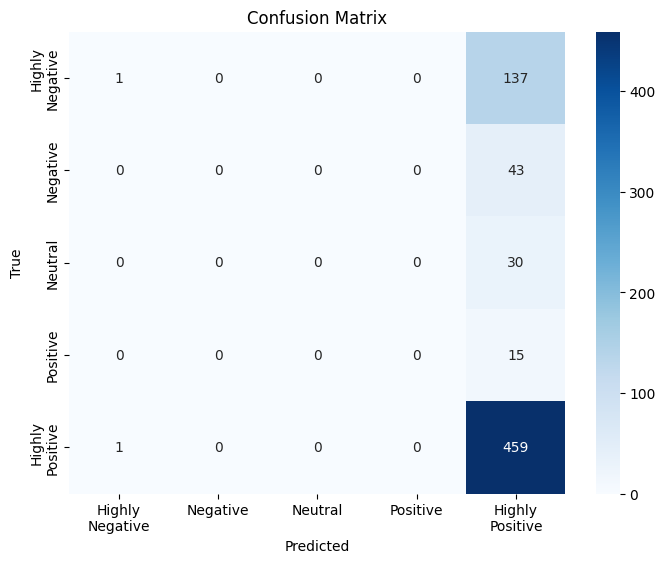

In [9]:
# Initialize the model
model = TextUnimodalModel()

# Handle class imbalance if needed
class_counts = Counter(convert_to_5class(traindata.dataset.dataset['labels']))
criterion = handle_class_imbalance(traindata, class_counts)

# Train the model
trained_model, train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model, traindata, validdata, num_epochs=50)

# Evaluate on test set
test_accuracy, test_precision, test_recall, test_f1, cm = evaluate_model(
    trained_model, testdata)

print(f'Test Accuracy: {test_accuracy:.4f}')
print(f'Test Precision: {test_precision:.4f}')
print(f'Test Recall: {test_recall:.4f}')
print(f'Test F1 Score: {test_f1:.4f}')

# Plot results
plot_results(train_losses, val_losses, train_accuracies, val_accuracies, cm)


In [12]:
def get_test_accuracy(model, test_loader):
    """
    Simple function to get just the test accuracy.
    
    Args:
        model: Trained model
        test_loader: Test data loader
    
    Returns:
        float: Test accuracy
    """
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            text = batch[2]
            labels = batch[3].squeeze()
            
            labels_5class = convert_to_5class(labels.numpy())
            
            outputs = model(text)
            _, predicted = torch.max(outputs.data, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels_5class)
    
    # Calculate accuracy
    accuracy = accuracy_score(all_labels, all_predictions)
    return accuracy

# Get just the test accuracy
test_accuracy = get_test_accuracy(trained_model, testdata)
print(f'Test Accuracy: {test_accuracy:.4f}')


Test Accuracy: 0.6706
